<a href="https://colab.research.google.com/github/ranran1231314/my_new_portfolio/blob/main/Final_Project_DRA_08_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is where I will write down my findings and directions of research

I will try to look for factors that influence traffic accidents

In [ ]:
#The influence of driver activity on the accidents - no data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   crash_date                     209306 non-null  object
 1   traffic_control_device         209306 non-null  object
 2   weather_condition              209306 non-null  object
 3   lighting_condition             209306 non-null  object
 4   first_crash_type               209306 non-null  object
 5   trafficway_type                209306 non-null  object
 6   alignment                      209306 non-null  object
 7   roadway_surface_cond           209306 non-null  object
 8   road_defect                    209306 non-null  object
 9   crash_type                     209306 non-null  object
 10  intersection_related_i         209306 non-null  object
 11  damage                         209306 non-null  object
 12  prim_contributory_cause        209306 non-nu

There are no nulls in the dataset

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib as plt

df = pd.read_csv('traffic_accidents.csv')
display(df.head())

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,7/29/2023 13:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,13,7,7
1,8/13/2023 0:11,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,2,0,1,8
2,12/9/2021 10:30,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,10,5,12
3,8/9/2023 19:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5,0,0,5,0,0,19,4,8
4,8/19/2023 14:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,14,7,8


In [ ]:
#The influence of the road on the accident - there is data.

contingency_table = pd.crosstab(df['roadway_surface_cond'], df['most_severe_injury'])

# Run the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Show results
print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-Value:", p)

# Optional: interpret result
alpha = 0.05
if p < alpha:
    print("➡️ There is a statistically significant relationship between surface condition and injury severity.")
else:
    print("➡️ No significant relationship between surface condition and injury severity.")



Chi-Square Statistic: 1047.8773148759399
Degrees of Freedom: 24
P-Value: 5.976656556363311e-206
➡️ There is a statistically significant relationship between surface condition and injury severity.


In [ ]:
print(contingency_table)

most_severe_injury    FATAL  INCAPACITATING INJURY  NO INDICATION OF INJURY  \
roadway_surface_cond                                                          
DRY                     287                   5152                   114368   
ICE                       3                     33                     1051   
OTHER                     1                     17                      303   
SAND, MUD, DIRT           0                      1                       29   
SNOW OR SLUSH             4                    112                     4975   
UNKNOWN                   7                    207                    10540   
WET                      49                   1042                    23523   

most_severe_injury    NONINCAPACITATING INJURY  REPORTED, NOT EVIDENT  
roadway_surface_cond                                                   
DRY                                      24114                  11984  
ICE                                        142                     74  


In [ ]:
fatalities_by_surface = (
    df.groupby("roadway_surface_cond")["injuries_fatal"]
    .sum()
    .reset_index()
    .sort_values(by="injuries_fatal", ascending=False)
)

print(fatalities_by_surface)


  roadway_surface_cond  injuries_fatal
0                  DRY             316
6                  WET              55
5              UNKNOWN               9
4        SNOW OR SLUSH               4
1                  ICE               4
2                OTHER               1
3      SAND, MUD, DIRT               0


Number of Accidents

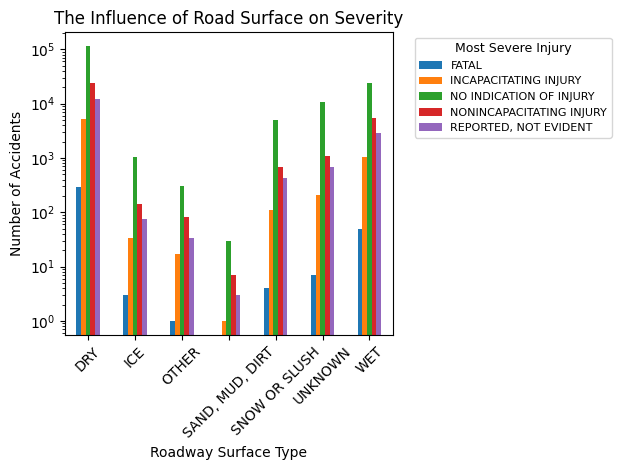

In [ ]:
import matplotlib.pyplot as plt

# Plot the contingency table as a grouped bar chart with log scale
ax = contingency_table.plot(kind='bar')

plt.title("The Influence of Road Surface on Severity")
plt.xlabel("Roadway Surface Type")
plt.ylabel("Number of Accidents")
plt.yscale("log")   # 🔑 log scale
plt.xticks(rotation=45)

# Move legend outside and make it smaller
plt.legend(title="Most Severe Injury", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()



In [ ]:
#The influence of the weather on the accident - there is data.

contingency_table = pd.crosstab(df['weather_condition'], df['most_severe_injury'])

# Run the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Show results
print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-Value:", p)

# Optional: interpret result
alpha = 0.05
if p < alpha:
    print("➡️ There is a statistically significant relationship between weather condition and injury severity.")
else:
    print("➡️ No significant relationship between weather condition and injury severity.")

Chi-Square Statistic: 844.7375586429603
Degrees of Freedom: 44
P-Value: 1.0491698106839652e-148
➡️ There is a statistically significant relationship between weather condition and injury severity.


In [ ]:
# Remove rows where most_severe_injury == "NO"
df_clean = df[df['most_severe_injury'] != "NO "]

# Rebuild contingency table
contingency_table = pd.crosstab(df_clean['weather_condition'], df_clean['most_severe_injury'])

# Optional: check categories
print(contingency_table.columns)



Index(['FATAL', 'INCAPACITATING INJURY', 'NO INDICATION OF INJURY',
       'NONINCAPACITATING INJURY', 'REPORTED, NOT EVIDENT'],
      dtype='object', name='most_severe_injury')


In [ ]:
print("Total fatalities in dataset:", df['injuries_fatal'].sum())
print("Fatalities included in grouped table:", injury_sums['injuries_fatal'].sum())

# Also check missing weather values
print("Rows with missing weather_condition:", df['weather_condition'].isna().sum())


Total fatalities in dataset: 389


KeyError: 'injuries_fatal'

In [ ]:
df['weather_condition'] = df['weather_condition'].fillna("UNKNOWN")


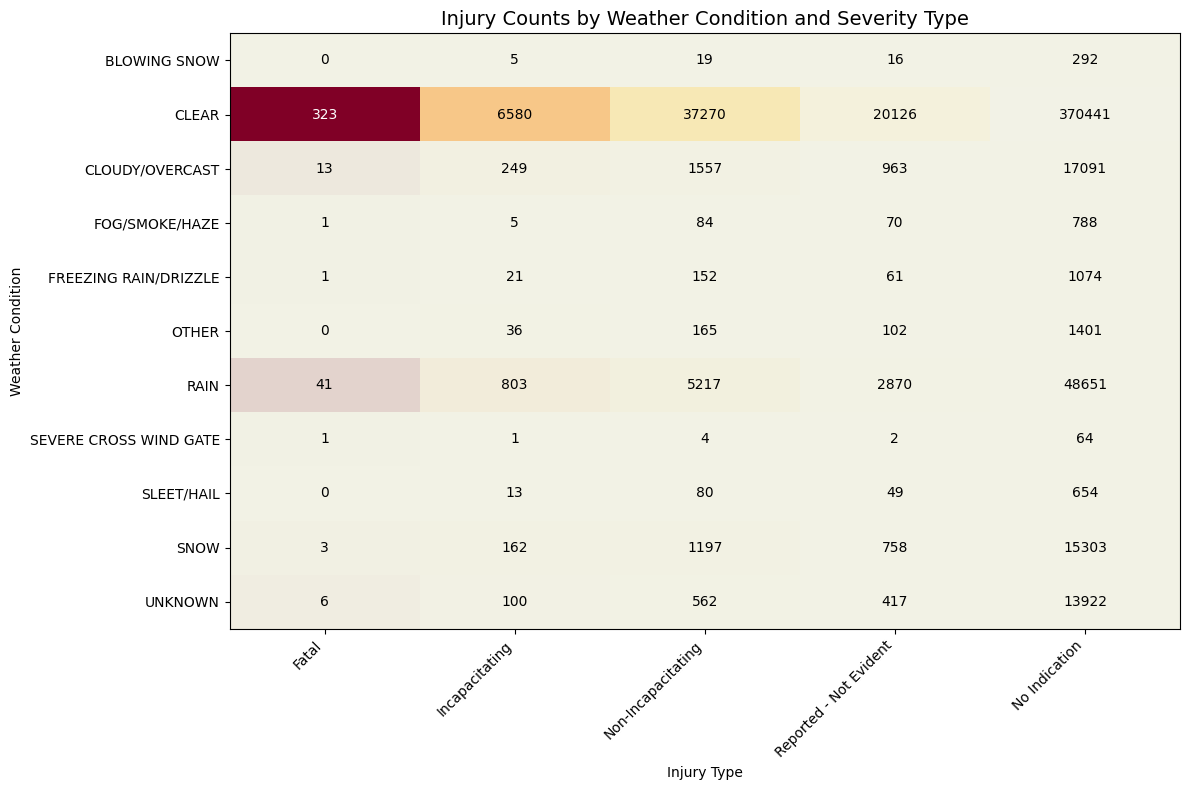

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Group and rename columns
injury_sums = df.groupby('weather_condition')[
    ['injuries_fatal',
     'injuries_incapacitating',
     'injuries_non_incapacitating',
     'injuries_reported_not_evident',
     'injuries_no_indication']
].sum()

injury_sums = injury_sums.rename(columns={
    'injuries_fatal': 'Fatal',
    'injuries_incapacitating': 'Incapacitating',
    'injuries_non_incapacitating': 'Non-Incapacitating',
    'injuries_reported_not_evident': 'Reported - Not Evident',
    'injuries_no_indication': 'No Indication'
})

# Remove row with almost no data
if 'BLOWING SAND, SOIL, DIRT' in injury_sums.index:
    injury_sums = injury_sums.drop('BLOWING SAND, SOIL, DIRT')

# Define base colors: only Fatal is red, others are soft neutral
base_colors = {
    'No Indication': "#f2f2e6",          # soft off-white
    'Reported - Not Evident': "#f4f1dc", # light cream
    'Non-Incapacitating': "#f7e8b5",     # soft yellow
    'Incapacitating': "#f7c788",         # light orange
    'Fatal': "#800026"                    # dark red
}

# Scale each column 0-1 for intensity
scaled = injury_sums.copy().astype(float)
for col in scaled.columns:
    max_val = scaled[col].max()
    scaled[col] = scaled[col] / max_val if max_val > 0 else 0

# Build RGBA color array
color_array = np.zeros(scaled.shape + (4,))
for i, col in enumerate(scaled.columns):
    base_rgb = mcolors.to_rgb(base_colors[col])
    for j in range(scaled.shape[0]):
        # Blend from soft off-white to base color
        color_array[j, i, :3] = (1 - scaled.iloc[j, i]) * np.array([0.95, 0.95, 0.9]) + scaled.iloc[j, i] * np.array(base_rgb)
        color_array[j, i, 3] = 1  # alpha

# Plot
fig, ax = plt.subplots(figsize=(12,8))
ax.imshow(color_array, aspect='auto')

# Add numbers with color adjustment for readability
for i in range(scaled.shape[0]):
    for j in range(scaled.shape[1]):
        bg_color = color_array[i, j, :3]
        brightness = np.mean(bg_color)
        txt_color = 'white' if brightness < 0.5 else 'black'
        ax.text(j, i, f"{injury_sums.iloc[i, j]:.0f}", ha='center', va='center', color=txt_color)

# Set ticks
ax.set_xticks(np.arange(len(scaled.columns)))
ax.set_xticklabels(scaled.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(scaled.index)))
ax.set_yticklabels(scaled.index)

ax.set_xlabel("Injury Type")
ax.set_ylabel("Weather Condition")
plt.title("Injury Counts by Weather Condition and Severity Type", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new column with upper case for display
df_clean['weather_condition_display'] = df_clean['weather_condition_clean'].str.upper()

# Rebuild contingency table
contingency_table = pd.crosstab(
    df_clean['weather_condition_display'],
    df_clean['most_severe_injury']
)

# 👉 Sum across severity types (row-wise)
total_injuries = contingency_table.sum(axis=1).to_frame(name="Total Injuries")

# Plot heatmap (just 1 column: totals)
plt.figure(figsize=(8,6))
sns.heatmap(total_injuries, annot=True, fmt="d", cmap="YlOrRd")

plt.title("Total Injuries per Weather Condition", fontsize=14)
plt.xlabel("Total Injuries")
plt.ylabel("Weather Condition")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



KeyError: 'weather_condition_clean'

In [ ]:
display(contingency_table)

we can see that on clear weather most of the fatal accidents happens, and then in rain. and then cloudy.

for incapacitating injuries most of them happen in a clear weather then in rain then in cloudy weather and then in snow.

one of the conclusions might be is that people mostly drive in a clear weather, or people feel the most safe in a clear weather therefore allowing themselves to drive fast and therefore making accidents.

In [ ]:
#I want to check if there is a connection between the casue of the crash and the damage

In [ ]:
contingency_table = pd.crosstab(df['prim_contributory_cause'], df['damage'])

# Run the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Show results
print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-Value:", p)

# Optional: interpret result
alpha = 0.05
if p < alpha:
    print("➡️ There is a statistically significant relationship between cause of the accident and damage.")
else:
    print("➡️ No significant relationship between cause of the accident and damage.")

Chi-Square Statistic: 6442.383815636307
Degrees of Freedom: 78
P-Value: 0.0
➡️ There is a statistically significant relationship between cause of the accident and damage.


it looks like there is a significant relationship between the cause of the accident and the damage

In [ ]:
display(contingency_table)

damage,$500 OR LESS,"$501 - $1,500","OVER $1,500"
prim_contributory_cause,,,
ANIMAL,10,8,31
BICYCLE ADVANCING LEGALLY ON RED LIGHT,11,6,15
CELL PHONE USE OTHER THAN TEXTING,37,47,170
DISREGARDING OTHER TRAFFIC SIGNS,73,135,891
DISREGARDING ROAD MARKINGS,61,59,216
DISREGARDING STOP SIGN,330,859,5560
DISREGARDING TRAFFIC SIGNALS,479,1421,12691
DISREGARDING YIELD SIGN,20,20,92
DISTRACTION - FROM INSIDE VEHICLE,167,231,877


check whether there is higher accidents in the weekend.

In [ ]:
contingency_table = pd.crosstab(df['crash_day_of_week'], df['damage'])
display(contingency_table)

damage,$500 OR LESS,"$501 - $1,500","OVER $1,500"
crash_day_of_week,,,
1,2070,4419,18757
2,2863,5627,19448
3,3140,6140,20794
4,3135,5907,21051
5,3345,6266,21176
6,3499,6976,23983
7,2731,5875,22104


it looks like there is a bit more accidents in the weekend. on the sixth day. saturday.

does number of injured imply on number of vehicles involved? maybe

it can be few injured in one car

In [ ]:
contingency_table = pd.crosstab(df['crash_hour'], df['damage'])
display(contingency_table)

damage,$500 OR LESS,"$501 - $1,500","OVER $1,500"
crash_hour,,,
0,314,637,3536
1,248,499,2982
2,163,398,2519
3,116,284,1964
4,101,255,1748
5,215,381,2223
6,490,787,3495
7,972,1739,6694
8,1238,2266,7877


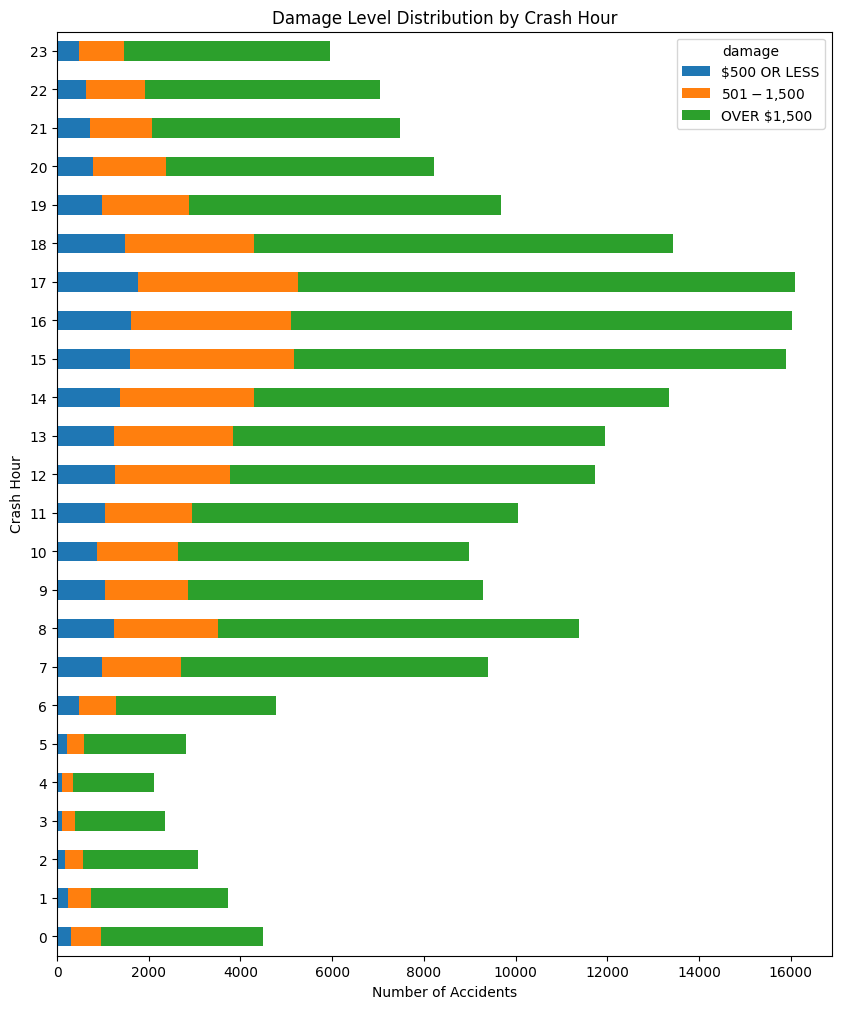

In [ ]:
import matplotlib.pyplot as plt

# plt.plot[kind=='barh', stacked==True](contingency_table)
contingency_table.plot(kind='barh', stacked=True, figsize=(10, 12))
plt.title('Damage Level Distribution by Crash Hour')
plt.xlabel('Number of Accidents')
plt.ylabel('Crash Hour')
plt.show()

most of the accidents happen at 17pm. at twilight hours, after the sunset. like zvika said these are the most dangerous hours.

In [ ]:
contingency_table = pd.crosstab(df['crash_day_of_week'], df['injuries_total'])
display(contingency_table)

injuries_total,0,1,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,19,21
crash_day_of_week,,,,,,,,,,,,,,,,,,,
1,18023,4678,1540,614,252,91,25,10,6,6,0,0,1,0,0,0,0,0,0
2,20632,5202,1383,459,157,60,21,15,4,2,0,1,0,0,1,0,0,0,1
3,22339,5683,1361,421,164,51,28,20,5,1,0,1,0,0,0,0,0,0,0
4,22291,5578,1456,502,147,67,33,9,4,0,3,0,0,0,1,0,1,0,1
5,22867,5758,1463,430,175,62,15,10,2,2,2,0,0,1,0,0,0,0,0
6,25988,6047,1578,516,205,70,38,4,5,0,1,2,1,0,2,0,0,1,0
7,22649,5432,1666,563,238,87,52,12,4,3,1,1,1,0,0,1,0,0,0


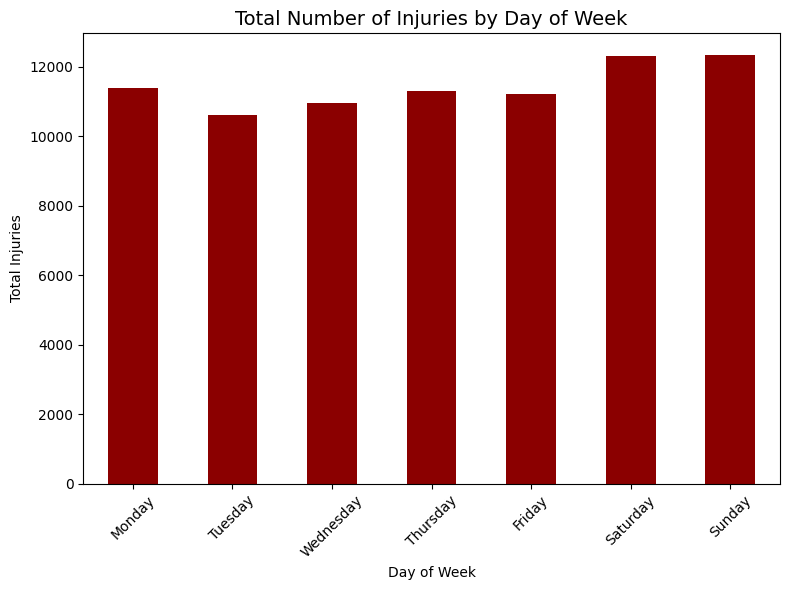

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Map numbers to weekday names
day_map = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

# Convert numbers into weekday names
df['day_of_week_name'] = df['crash_day_of_week'].map(day_map)

# Define correct order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 👇 Sum the injuries per weekday (replace 'injury_count' with your actual column name)
injuries_per_day = (
    df.groupby('day_of_week_name')['injuries_total']
      .sum()
      .reindex(weekday_order)
)

# Plot bar chart
injuries_per_day.plot(kind='bar', figsize=(8,6), color="darkred")

plt.title('Total Number of Injuries by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Total Injuries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
from scipy.stats import chisquare

# Map numbers to weekday names
day_map = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

# Convert numbers into weekday names
df['day_of_week_name'] = df['crash_day_of_week'].map(day_map)

# Define correct order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Count number of accidents per day of week
accidents_per_day = (
    df['day_of_week_name']
    .value_counts()
    .reindex(weekday_order)
)

# Run Chi-Square Goodness of Fit test
chi2_stat, p_value = chisquare(f_obs=accidents_per_day)

print("Accidents per Day:\n", accidents_per_day)
print(f"\nChi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ There is a significant difference in accident counts across days of the week.")
else:
    print("❌ No significant difference in accident counts across days of the week.")


Accidents per Day:
 day_of_week_name
Monday       25246
Tuesday      27938
Wednesday    30074
Thursday     30093
Friday       30787
Saturday     34458
Sunday       30710
Name: count, dtype: int64

Chi-square statistic: 1598.45
P-value: 0.0000
✅ There is a significant difference in accident counts across days of the week.


In [ ]:
contingency_table = pd.crosstab(df['first_crash_type'], df['most_severe_injury'])
display(contingency_table)

In [ ]:
contingency_table.plot(kind='bar', figsize=(10, 12))
plt.title('Most severe injury by first crash type')
plt.xlabel('First_Crash_Type')
plt.ylabel('Number_of_accidents')
plt.show()

Most of the fatal accidents are when angle is the first crash, and the second is pedestrian. means walkers on the pavement. more than 60% percents of the pedestrian deaths are when people are jaywalking.

A/B Testing - Not to calculate. We need to do it theoretic.

Test group

We want to do it with a data we want that will be.

Group A - as much specific in terms of characteristics

Group B - similar to Group A with slight variation.

Slide - target - Group A, Group B.
Assumption

done

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("traffic_accidents.csv")

# Group by primary contributory cause and sum total injuries
injuries_by_cause = (
    df.groupby("prim_contributory_cause")["injuries_total"]
    .sum()
    .reset_index()
    .sort_values(by="injuries_total", ascending=False)
)

# Display results
print(injuries_by_cause)

injuries_by_cause.plot(kind = 'bar', figsize=(12,8))
plt.title('Total Injuries by Primary Contributory Cause')
plt.xlabel('Primary Contributory Cause')
plt.ylabel('Total Injuries')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("traffic_accidents.csv")

# Group by primary contributory cause and sum total injuries
injuries_by_cause = (
    df.groupby("prim_contributory_cause")["injuries_total"]
    .sum()
    .reset_index()
    .sort_values(by="injuries_total", ascending=False)
    .reset_index(drop=True)
)

# Add ranking numbers
injuries_by_cause.index = injuries_by_cause.index + 1  # start rank from 1
injuries_by_cause.index.name = "Rank"

# Format injuries with commas for readability
injuries_by_cause["injuries_total"] = injuries_by_cause["injuries_total"].apply(lambda x: f"{x:,}")

# Show table
print(injuries_by_cause)


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("traffic_accidents.csv")

# Group by primary contributory cause and sum total injuries
injuries_by_cause = (
    df.groupby("prim_contributory_cause")["injuries_total"]
    .sum()
    .reset_index()
    .sort_values(by="injuries_total", ascending=False)
    .reset_index(drop=True)
)

# Keep only top 20
injuries_top20 = injuries_by_cause.head(20)

# Add ranking numbers
injuries_top20.index = injuries_top20.index + 1  # start rank from 1
injuries_top20.index.name = "Rank"

# Format numbers with commas for readability
injuries_top20["injuries_total"] = injuries_top20["injuries_total"].apply(lambda x: f"{x:,}")

# Show table
print(injuries_top20.to_string())


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("traffic_accidents.csv")

# Group by primary contributory cause and sum total injuries
injuries_by_cause = (
    df.groupby("prim_contributory_cause")["injuries_total"]
    .sum()
    .reset_index()
    .sort_values(by="injuries_total", ascending=False)
    .reset_index(drop=True)
)

# Keep only top 13
injuries_top13 = injuries_by_cause.head(13)

# Add ranking numbers (1–13)
injuries_top13.index = injuries_top13.index + 1
injuries_top13.index.name = "Rank"

# Rename the 11th ranked cause to AGGRESSIVE DRIVING
injuries_top13.loc[11, "prim_contributory_cause"] = "AGGRESSIVE DRIVING"

# Plot bar chart
plt.figure(figsize=(12, 7))
bars = plt.barh(
    injuries_top13["prim_contributory_cause"],
    injuries_top13["injuries_total"],
    color="skyblue"
)

# Invert Y-axis so Rank 1 is at the top
plt.gca().invert_yaxis()

# Remove chart frame (spines)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Add labels
plt.xlabel("Total Injuries")
plt.title("Top 13 Primary Contributory Causes of Injuries")

# Add numbers at the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(injuries_top13["injuries_total"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,}",
        va="center"
    )

plt.tight_layout()
plt.show()
